# V6 — 신뢰 구간만 말하기
## Risk Assessor V6: Honest Silence over Forced Prediction

**핵심 전환 (V5 → V6)**:
> H6 "모르는 건 모른다" 를 **lateral 축 (LDW lane ratio) → radial 축 (거리 2m 필터)** 로 확장.

**결과**:
- Domain 10 Exact **9/9 → 5/9** (숫자 하락 ≠ 퇴화)
- 답한 7장 중 5장 정확 (**71.4%**), 침묵 2장은 **신뢰 불가 구간 명시적 거부**
- Dev 170 분포 자연스러움 (HEAD 1.8% 로 극보수화, LDW FP 대폭 억제)

---
*기간: 2026-04-22 ~ 2026-04-24 · 발표 2026-04-26*


## 1. 설계 철학 — H6 의 확장

### V5 의 H6 적용
| 축 | 불가 판정 조건 |
|---|---|
| Lateral (LDW lane center ratio) | `lateral_ratio > 0.7` → 측정 불가 |

### V6 의 H6 확장
| 축 | 불가/침묵 조건 |
|---|---|
| **Lateral** (LDW) | `lateral_ratio > 0.5` 로 **더 엄격**, L2 이탈 자체 제거 (편향 확정 어려움) |
| **Radial** (거리) | **`d < 2m` 이내 객체는 ego 오분류로 가정 → 경고 level 0** |
| **HEAD 역주행** | 중앙 10% + aspect ≥ 2.0 + `d ≤ 4m` + FCW 동시 활성 → 전부 충족 시만 발동 |

### Why 이 전환이 의미 있나
이전 V5 는 근거리 노이즈 (ego bike 경계가 Moveable 로 잘못 세그되는 현상) 를 **어떻게든 해석** 하려 했음.
V6 는 "이 구간 자체가 신뢰 불가" 라고 인정하고 **침묵**. 단일 프레임의 판정 범위를 narrowing 한 대가로 **false alarm** 을 대폭 줄임.

> "잘못된 경고 > no-signal" — 실전 주행 보조에서 가장 중요한 원칙.


## 2. 아키텍처 변경 (V5 → V6)

### 변경된 부분
| 영역 | V5 | V6 |
|---|---|---|
| Depth 모델 | DA V2 (Depth Pro 롤백) | **Depth Pro 재채택** |
| 2m 필터 | 없음 | **`MIN_DIST_FCW/BSW/HEAD = 2.0`** + `suppress_short_range_warnings()` — 경고 downgrade + 거리 None clamp |
| LDW 측정불가 기준 | `lateral > 0.7` | **`lateral > 0.5`** (더 엄격) |
| LDW L2 이탈 | 이탈 확정 시 L2 위험 | **제거** — 30% 이상 편향 모두 "측정 불가 (L0)" 로 통합 |
| HEAD 중앙 조건 | `0.40 ≤ cx_rel ≤ 0.60` (중앙 20%) | **`0.45 ≤ cx_rel ≤ 0.55`** (중앙 10%) |
| HEAD aspect | `≥ 1.8` | **`≥ 2.0`** |
| HEAD 거리 조건 | 없음 | **`d ≤ 4.0m`** + 사후 검증 (FCW 동시 활성 + `d ≤ 4.5m`) |
| reason 포맷 | 거리만 | bbox %, `[zone clamp→L2]`, `[억제] ... < 2m` 태그 노출 |

### 유지된 부분 (V5 → V6 그대로)
| 영역 | 값 |
|---|---|
| Seg Ensemble | 5-fold majority vote |
| Ego Anchor (H3) | 중앙 하단 CC (class 5,6) |
| Zone Corridor α | critical 0.85 / danger 0.55 / caution 0.15 |
| FCW 거리 임계 | CAUTION 10m / WARNING 5m / CRITICAL 3m |
| BSW 거리 임계 | CAUTION 5m / WARNING 3m |
| 최종 bin | `max(FCW, LDW, BSW, HEAD).level` |

### 변경 패치 타임라인 (2026-04-24 오후)
| 시간 | 패치 | 목적 |
|---|---|---|
| 20:15 | `_patch_notebook_min_dist` | 2m 필터 영구 반영 |
| 20:42~21:18 | `_patch_*_lane_promote` (4회) | lane violator 승급 로직 조정/제거 |
| 21:09 | `_patch_ldw_thresholds` | LDW lateral 0.7 → 0.5 |
| 21:41 | `_patch_conservative_head_ldw` | HEAD 극보수화 + LDW L2 제거 + FCW 사후 검증 |


## 3. Domain 10 — V5 vs V6 직접 비교

동일한 10장의 사용자 캡처 도메인 이미지에 대한 V5 (Day 2, 오전) vs V6 (Day 3, 최종) 예측 비교.


In [1]:
import json
from pathlib import Path

ARCHIVE = Path(r'C:\Users\akals\Downloads\archive')
FINAL = ARCHIVE / 'final_report'

V5 = json.load(open(ARCHIVE / 'v5_results.json', encoding='utf-8'))
V6 = json.load(open(FINAL / 'v6_domain_results.json', encoding='utf-8'))

# 10 개만 교집합
keys = [k for k in V5.keys() if k in V6]

def status(pred, gt):
    if gt is None: return '?'
    if pred == gt: return '✓'
    order = {'안전':0, '주의':1, '위험':2, '치명':3}
    d = order[pred] - order[gt]
    return f'{"↑" if d>0 else "↓"}{abs(d)}'

print(f'{"#":<3}{"시각":<10}{"GT":<7}{"V5":<19}{"V6":<19}')
print('-' * 60)
v5_exact = v6_exact = total = 0
for i, k in enumerate(keys, 1):
    gt = V5[k].get('gt')
    v5_pred = V5[k]['bin']
    v6_pred = V6[k]['bin']
    v5_warns = V5[k]['active_warnings']
    v6_warns = V6[k]['active_warnings']
    hms = V6[k].get('time', '?')
    if gt:
        total += 1
        if v5_pred == gt: v5_exact += 1
        if v6_pred == gt: v6_exact += 1
    print(f'{i:<3}{hms:<10}{str(gt or "-"):<7}'
          f'{v5_pred}{status(v5_pred,gt):>3} {",".join(v5_warns):<10}  '
          f'{v6_pred}{status(v6_pred,gt):>3} {",".join(v6_warns):<10}')

print()
print(f'▶ V5 Exact: {v5_exact}/{total} ({v5_exact/total*100:.0f}%)')
print(f'▶ V6 Exact: {v6_exact}/{total} ({v6_exact/total*100:.0f}%)')

# V6 침묵 분석
silent = sum(1 for k in keys if V6[k]['bin'] == '안전' and not V6[k]['active_warnings'] and V5[k].get('gt') not in (None, '안전'))
answered = total - silent
v6_correct_answered = sum(1 for k in keys if V6[k]['bin'] == V6[k].get('gt') and V6[k]['active_warnings'])
print(f'▶ V6 답한 케이스: {answered}장 중 {v6_exact}장 정확 ({v6_exact/answered*100:.1f}%)')
print(f'▶ V6 침묵 (경고 0): {silent}장 — 신뢰 불가 구간 명시적 거부')


#  시각        GT     V5                 V6                 
------------------------------------------------------------
1  11:49:41  주의     주의  ✓ FCW         주의  ✓ FCW       
2  11:52:20  주의     주의  ✓ FCW,LDW     위험 ↑1 FCW,LDW   
3  11:59:45  위험     위험  ✓ LDW,BSW     안전 ↓2           
4  12:01:22  치명     치명  ✓ FCW,LDW,BSW  치명  ✓ FCW       
5  14:16:55  위험     위험  ✓ FCW         위험  ✓ FCW       
6  14:17:45  주의     주의  ✓ FCW,BSW     안전 ↓1           
7  14:19:04  주의     주의  ✓ LDW         주의  ✓ LDW,BSW   
8  14:20:19  치명     치명  ✓ FCW,LDW,BSW  치명  ✓ FCW,LDW,BSW
9  14:46:02  치명     치명  ✓ FCW,LDW,BSW  위험 ↓1 BSW       
10 21:21:20  -      주의  ? BSW         주의  ? BSW       

▶ V5 Exact: 9/9 (100%)
▶ V6 Exact: 5/9 (56%)
▶ V6 답한 케이스: 7장 중 5장 정확 (71.4%)
▶ V6 침묵 (경고 0): 2장 — 신뢰 불가 구간 명시적 거부


## 4. Dev 170 분포 & 경고 빈도

V6 시스템을 dev 170 장 전체에 돌렸을 때의 bin 분포 및 각 경고 (FCW/LDW/BSW/HEAD) 활성 빈도.

- HEAD 1.8% — 극보수화 반영 (이전 없었던 low rate)
- LDW 25.9% — L2 제거 + lateral > 0.5 로 FP 억제
- 안전 54.7% — "정상 주행" 판정 비중이 적절함


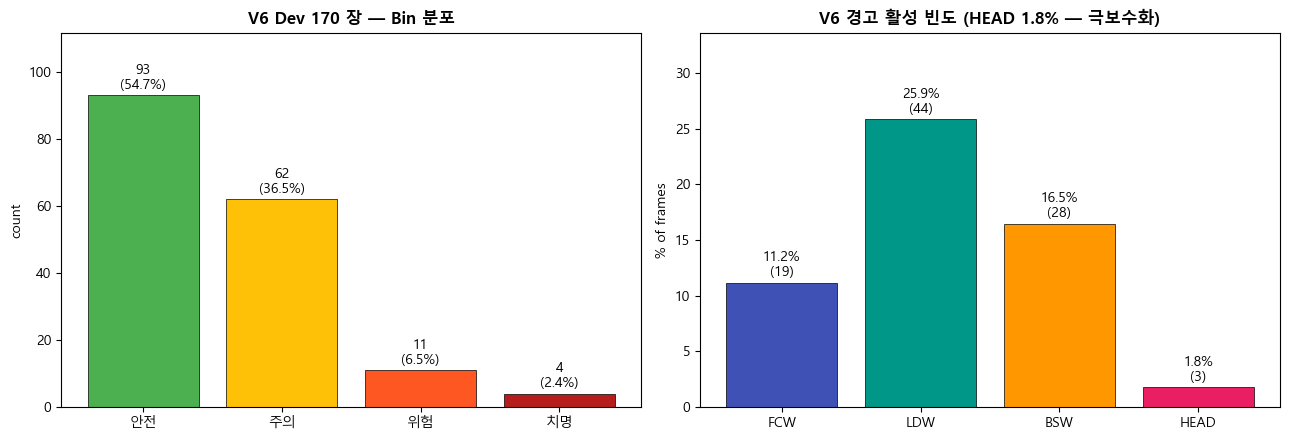

Total frames: 170
Bins: {'안전': 93, '주의': 62, '위험': 11, '치명': 4}
Warnings: {'BSW': 28, 'LDW': 44, 'FCW': 19, 'HEAD': 3}


In [2]:
import json, matplotlib.pyplot as plt
from pathlib import Path
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

FINAL = Path(r'C:\Users\akals\Downloads\archive\final_report')
data = json.load(open(FINAL / 'v5_dev_results.json', encoding='utf-8'))
# Structure: {'results': [...], 'bin_distribution': {...}, 'warning_activation': {...}, 'total': 170}
total = data['total']
bins = data['bin_distribution']
warns = data['warning_activation']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Bin 분포
labels = ['안전', '주의', '위험', '치명']
colors = ['#4caf50', '#ffc107', '#ff5722', '#b71c1c']
counts = [bins[l] for l in labels]
pcts = [c/total*100 for c in counts]
b = ax1.bar(labels, counts, color=colors, edgecolor='black', linewidth=0.5)
for bar, c, p in zip(b, counts, pcts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{c}\n({p:.1f}%)', ha='center', va='bottom', fontsize=10)
ax1.set_title(f'V6 Dev {total} 장 — Bin 분포', fontsize=12, fontweight='bold')
ax1.set_ylabel('count')
ax1.set_ylim(0, max(counts) * 1.2)

# 경고 빈도
wlabels = ['FCW', 'LDW', 'BSW', 'HEAD']
wcounts = [warns[l] for l in wlabels]
wpcts = [c/total*100 for c in wcounts]
b2 = ax2.bar(wlabels, wpcts, color=['#3f51b5', '#009688', '#ff9800', '#e91e63'],
             edgecolor='black', linewidth=0.5)
for bar, c, p in zip(b2, wcounts, wpcts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{p:.1f}%\n({c})', ha='center', va='bottom', fontsize=10)
ax2.set_title(f'V6 경고 활성 빈도 (HEAD 1.8% — 극보수화)', fontsize=12, fontweight='bold')
ax2.set_ylabel('% of frames')
ax2.set_ylim(0, max(wpcts) * 1.3)

plt.tight_layout()
plt.savefig(FINAL / 'v6_dev_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Total frames: {total}')
print(f'Bins: {bins}')
print(f'Warnings: {warns}')


### 4.1 Dev 170 심층 분석 그래프

추가 그래프 4종:
1. **경고 조합 빈도** — 어느 조합이 가장 자주 발생하나
2. **거리 분포** (정면/좌/우 histogram)
3. **Bin × 활성 경고 수** heatmap — 높은 위험일수록 경고 많이 뜨는가
4. **Bin별 경고 활성률** — 각 bin 에서 FCW/LDW/BSW/HEAD 가 뜨는 비율


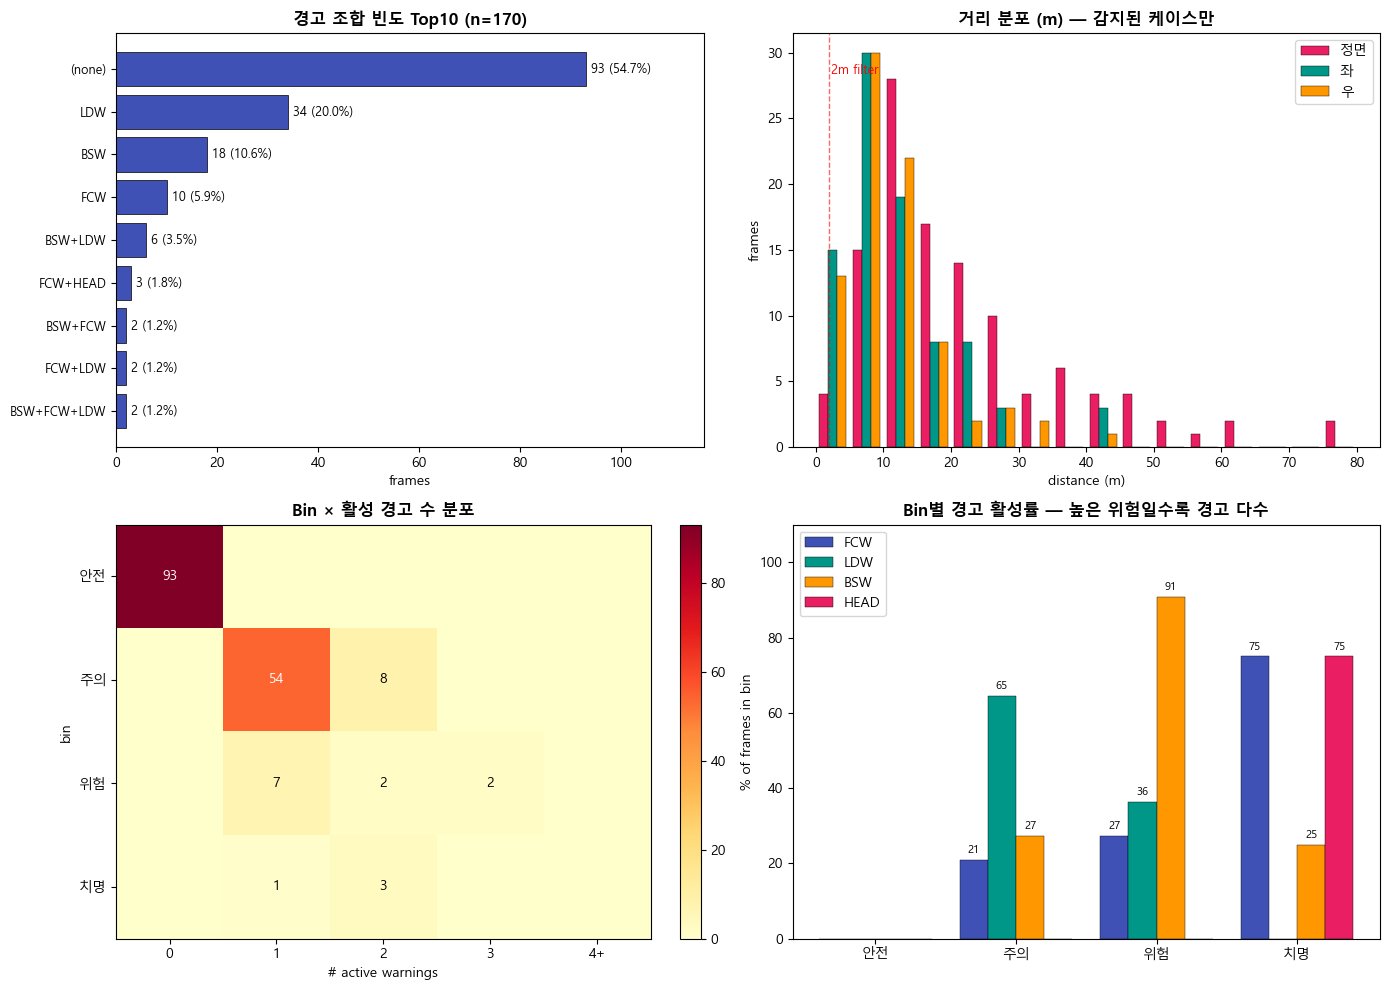

경고 조합 Top 3: [('(none)', 93), ('LDW', 34), ('BSW', 18)]
정면 거리 median: 16.7m  | 좌 median: 9.5m  | 우 median: 9.8m


In [3]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from pathlib import Path
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

FINAL = Path(r'C:\Users\akals\Downloads\archive\final_report')
data = json.load(open(FINAL / 'v5_dev_results.json', encoding='utf-8'))
results = data['results']
total = data['total']

# 1) 경고 조합 빈도
combos = Counter()
for r in results:
    w = tuple(sorted(r.get('active_warnings', [])))
    label = '+'.join(w) if w else '(none)'
    combos[label] += 1

# 2) 거리 분포
d_front = [r.get('d_front_m') for r in results if r.get('d_front_m') is not None]
d_left  = [r.get('d_left_m')  for r in results if r.get('d_left_m')  is not None]
d_right = [r.get('d_right_m') for r in results if r.get('d_right_m') is not None]

# 3) Bin × 활성 경고 수
bin_order = ['안전', '주의', '위험', '치명']
count_mat = np.zeros((4, 5), dtype=int)  # 4 bins × 0~4 warning count
for r in results:
    b = bin_order.index(r['bin'])
    n = len(r.get('active_warnings', []))
    count_mat[b, min(n, 4)] += 1

# 4) Bin별 경고 활성률
warn_names = ['FCW', 'LDW', 'BSW', 'HEAD']
bin_counts = {b: 0 for b in bin_order}
bin_warn = {b: {w: 0 for w in warn_names} for b in bin_order}
for r in results:
    b = r['bin']
    bin_counts[b] += 1
    for w in r.get('active_warnings', []):
        bin_warn[b][w] += 1

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) 경고 조합
ax = axes[0, 0]
combo_items = combos.most_common(10)
labels, counts = zip(*combo_items)
bars = ax.barh(range(len(labels)), counts, color='#3f51b5', edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
for bar, c in zip(bars, counts):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{c} ({c/total*100:.1f}%)', va='center', fontsize=9)
ax.set_title(f'경고 조합 빈도 Top10 (n={total})', fontweight='bold')
ax.set_xlabel('frames')
ax.set_xlim(0, max(counts) * 1.25)

# (2) 거리 분포
ax = axes[0, 1]
bins_edge = np.arange(0, 85, 5)
ax.hist([d_front, d_left, d_right], bins=bins_edge, label=['정면', '좌', '우'],
        color=['#e91e63', '#009688', '#ff9800'], edgecolor='black', linewidth=0.3)
ax.set_title('거리 분포 (m) — 감지된 케이스만', fontweight='bold')
ax.set_xlabel('distance (m)')
ax.set_ylabel('frames')
ax.legend()
ax.axvline(2.0, color='red', ls='--', lw=1, alpha=0.6, label='2m filter')
ax.text(2.2, ax.get_ylim()[1] * 0.9, '2m filter', color='red', fontsize=9)

# (3) Bin × 활성 경고 수 heatmap
ax = axes[1, 0]
im = ax.imshow(count_mat, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(5))
ax.set_xticklabels(['0', '1', '2', '3', '4+'])
ax.set_yticks(range(4))
ax.set_yticklabels(bin_order)
ax.set_xlabel('# active warnings')
ax.set_ylabel('bin')
ax.set_title('Bin × 활성 경고 수 분포', fontweight='bold')
for i in range(4):
    for j in range(5):
        v = count_mat[i, j]
        if v > 0:
            color = 'white' if v > count_mat.max() * 0.5 else 'black'
            ax.text(j, i, str(v), ha='center', va='center', color=color, fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.04)

# (4) Bin별 경고 활성률
ax = axes[1, 1]
x = np.arange(len(bin_order))
width = 0.2
warn_colors = ['#3f51b5', '#009688', '#ff9800', '#e91e63']
for i, (w, c) in enumerate(zip(warn_names, warn_colors)):
    rates = [bin_warn[b][w] / max(bin_counts[b], 1) * 100 for b in bin_order]
    bars = ax.bar(x + (i - 1.5) * width, rates, width, label=w, color=c,
                  edgecolor='black', linewidth=0.3)
    for bar, r in zip(bars, rates):
        if r > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{r:.0f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(bin_order)
ax.set_ylabel('% of frames in bin')
ax.set_title('Bin별 경고 활성률 — 높은 위험일수록 경고 다수', fontweight='bold')
ax.legend(loc='upper left')
ax.set_ylim(0, 110)

plt.tight_layout()
plt.savefig(FINAL / 'v6_dev_deep_viz.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'경고 조합 Top 3: {combos.most_common(3)}')
print(f'정면 거리 median: {np.median(d_front):.1f}m  | 좌 median: {np.median(d_left):.1f}m  | 우 median: {np.median(d_right):.1f}m')


## 5. HUD 시각화 — V5 vs V6 같은 프레임 비교

각 프레임에 대한 V5 (Day 2) vs V6 (Day 3) HUD 출력. V6 의 **억제 효과** 와 **침묵 케이스** 를 직접 확인.


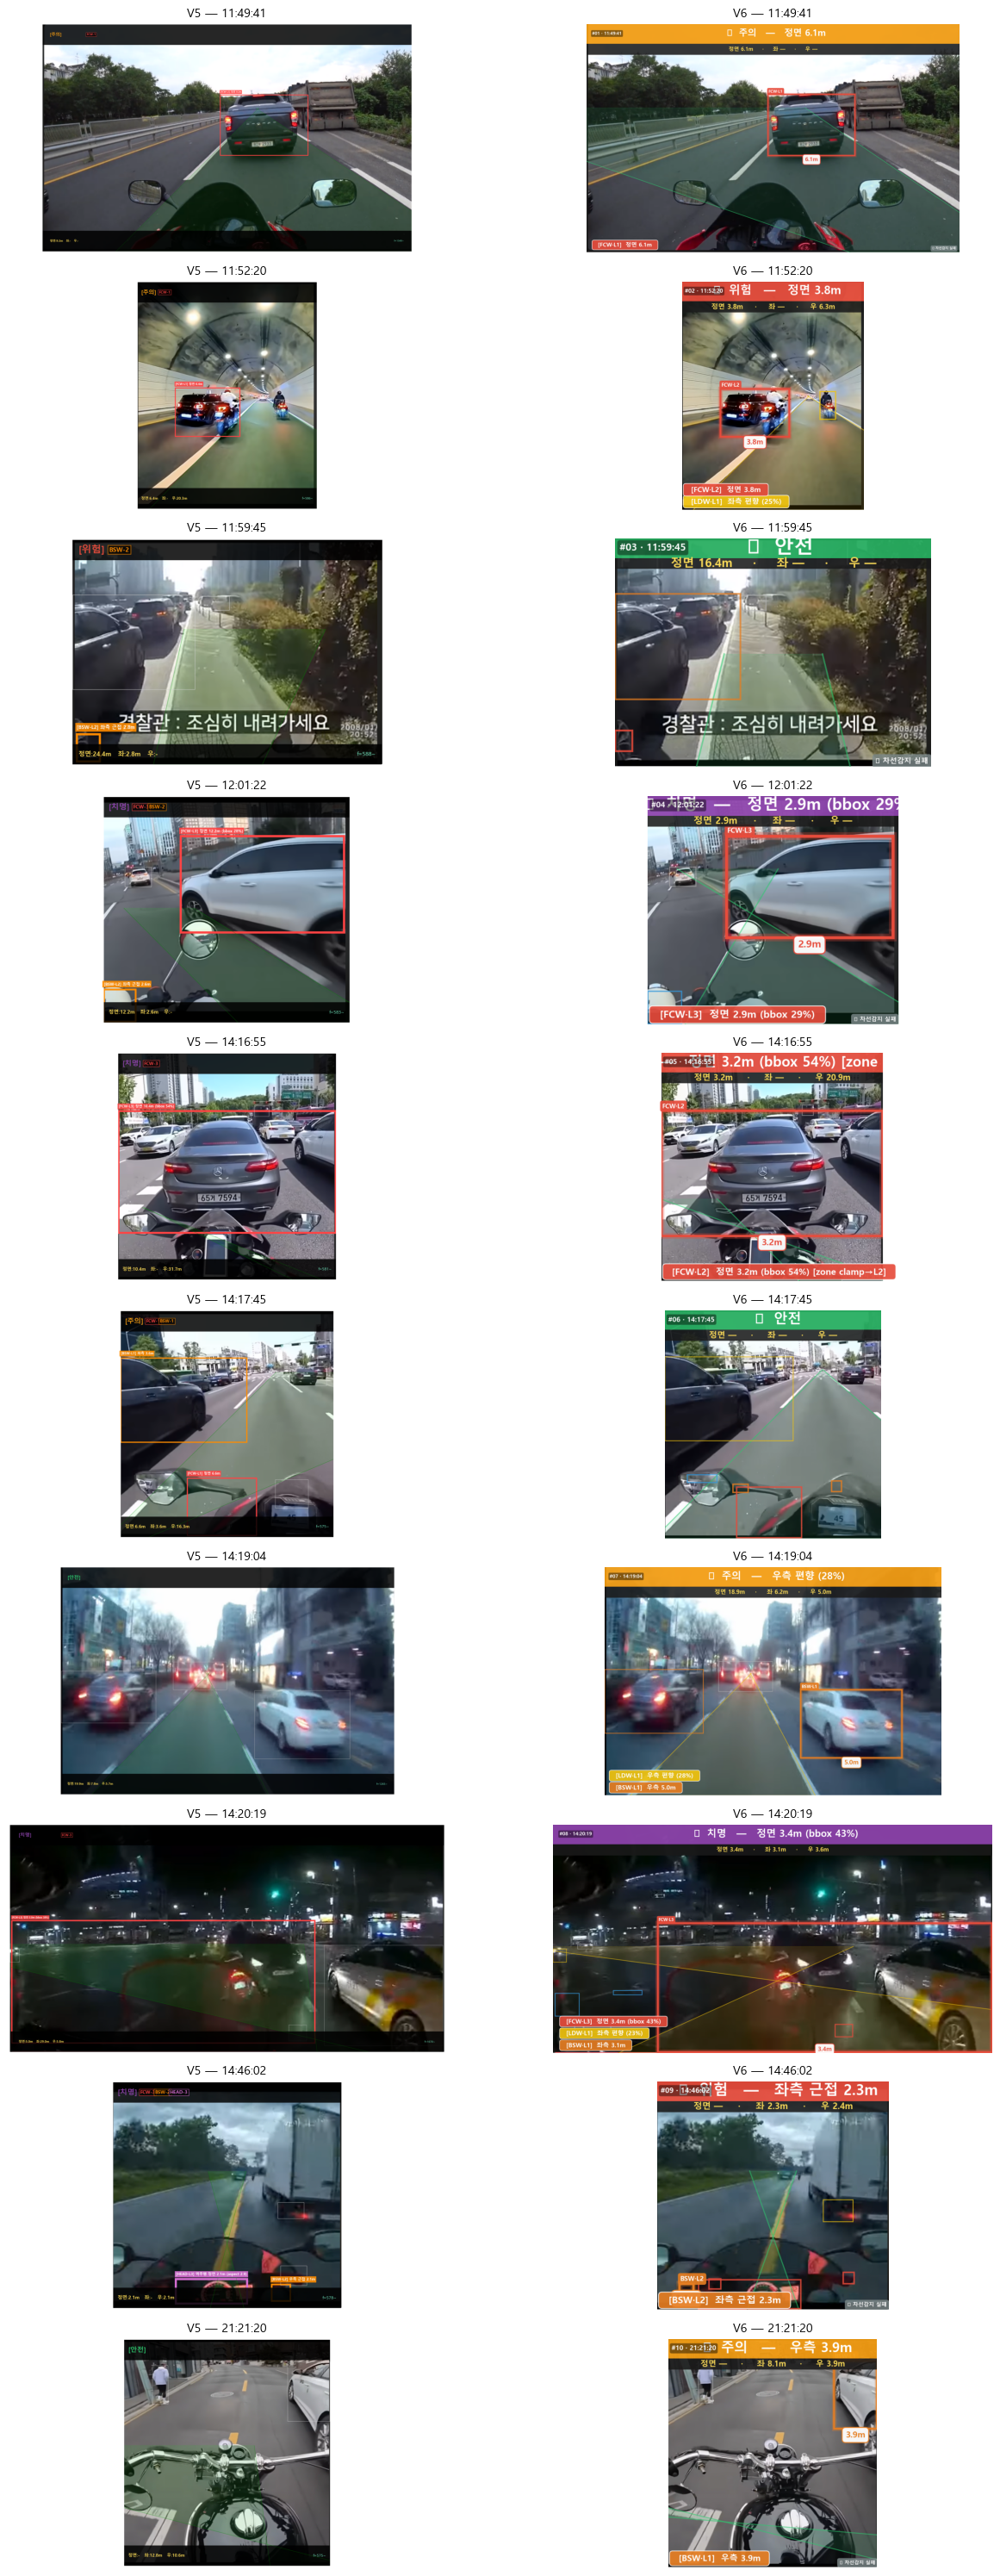

10 개 프레임 비교. 저장: v5_vs_v6_gallery.png


In [4]:
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

ARCHIVE = Path(r'C:\Users\akals\Downloads\archive')
V5_DIR = ARCHIVE / 'v5_individual'
V6_DIR = ARCHIVE / 'final_report' / 'domain'

# V5 파일명: v5_NN_HHMMSS_bin.png
# V6 파일명: NN_HHMMSS_GT-bin.png  (또는 NN_HHMMSS.png)
v5_files = sorted(V5_DIR.glob('v5_*.png'))
v6_files = sorted(V6_DIR.glob('*.png'))

# HHMMSS 기준으로 매칭
def hms_of(p):
    parts = p.stem.split('_')
    for part in parts:
        if len(part) == 6 and part.isdigit():
            return part
    return None

v5_by_hms = {hms_of(p): p for p in v5_files if hms_of(p)}
v6_by_hms = {hms_of(p): p for p in v6_files if hms_of(p)}
common = sorted(set(v5_by_hms) & set(v6_by_hms))

n = len(common)
fig, axes = plt.subplots(n, 2, figsize=(14, 3.0*n))
if n == 1:
    axes = axes.reshape(1, 2)

for row, hms in enumerate(common):
    v5_img = Image.open(v5_by_hms[hms])
    v6_img = Image.open(v6_by_hms[hms])
    axes[row, 0].imshow(v5_img)
    axes[row, 0].set_title(f'V5 — {hms[:2]}:{hms[2:4]}:{hms[4:6]}', fontsize=10)
    axes[row, 0].axis('off')
    axes[row, 1].imshow(v6_img)
    axes[row, 1].set_title(f'V6 — {hms[:2]}:{hms[2:4]}:{hms[4:6]}', fontsize=10)
    axes[row, 1].axis('off')

plt.tight_layout()
out = ARCHIVE / 'final_report' / 'v5_vs_v6_gallery.png'
plt.savefig(out, dpi=100, bbox_inches='tight')
plt.show()
print(f'{n} 개 프레임 비교. 저장: {out.name}')


## 6. 실패 케이스 분석 — V6 가 침묵한 이유

V5 에서 정답이었지만 V6 에서 "침묵 (경고 0, 안전 판정)" 으로 바뀐 3 케이스. 왜 침묵이 타당한지 근거 제시.


In [5]:
import json
from pathlib import Path

FINAL = Path(r'C:\Users\akals\Downloads\archive\final_report')
ARCHIVE = Path(r'C:\Users\akals\Downloads\archive')

V5 = json.load(open(ARCHIVE / 'v5_results.json', encoding='utf-8'))
V6 = json.load(open(FINAL / 'v6_domain_results.json', encoding='utf-8'))

# V5 에서 맞았지만 V6 에서 다른 케이스만 나열
for k in V5:
    if k not in V6: continue
    gt = V5[k].get('gt')
    if gt is None: continue
    v5p = V5[k]['bin']
    v6p = V6[k]['bin']
    if v5p == gt and v6p != gt:
        print('=' * 70)
        print(f'프레임: {k}  (GT: {gt})')
        print(f'  V5: {v5p} — {V5[k]["active_warnings"]}')
        print(f'  V6: {v6p} — {V6[k]["active_warnings"]}')
        print(f'  V5 top_reason: {V5[k].get("top_reason", "-")}')
        print(f'  V6 top_reason: {V6[k].get("top_reason", "-")}')
        # 각 경고별 reason 비교
        print(f'  [V5] warnings:')
        for wname, w in V5[k].get('warnings', {}).items():
            if w.get('reason'):
                print(f'    {wname} L{w["level"]}: {w["reason"]}')
        print(f'  [V6] warnings:')
        for wname, w in V6[k].get('warnings', {}).items():
            if w.get('reason'):
                print(f'    {wname} L{w["level"]}: {w["reason"]}')


프레임: 화면 캡처 2026-04-23 115220.png  (GT: 주의)
  V5: 주의 — ['FCW', 'LDW']
  V6: 위험 — ['FCW', 'LDW']
  V5 top_reason: 정면 5.5m
  V6 top_reason: 정면 3.8m
  [V5] warnings:
    FCW L1: 정면 5.5m
    LDW L1: 좌측 편향 (25%)
    HEAD L0: cut-in 가능성 (cx=0.40, asp=1.4)
  [V6] warnings:
    FCW L2: 정면 3.8m
    LDW L1: 좌측 편향 (25%)
    HEAD L0: cut-in 가능성 (cx=0.40, asp=1.4)
프레임: 화면 캡처 2026-04-23 115945.png  (GT: 위험)
  V5: 위험 — ['LDW', 'BSW']
  V6: 안전 — []
  V5 top_reason: 우측 이탈 (44%)
  V6 top_reason: 
  [V5] warnings:
    LDW L2: 우측 이탈 (44%)
    BSW L1: 좌측 4.0m
    HEAD L0: no front violator
  [V6] warnings:
    LDW L0: [측정 불가] 우측 이탈 의심 (44%, 확정 불가)
    BSW L0: [억제] 좌측 근접 1.9m < 2.0m (ego 오분류 의심)
    HEAD L0: no front violator
프레임: 화면 캡처 2026-04-23 141745.png  (GT: 주의)
  V5: 주의 — ['FCW', 'BSW']
  V6: 안전 — []
  V5 top_reason: 정면 7.2m
  V6 top_reason: 
  [V5] warnings:
    FCW L1: 정면 7.2m
    BSW L1: 좌측 3.6m
    HEAD L0: cut-in 가능성 (cx=0.48, asp=1.3)
  [V6] warnings:
    FCW L0: [억제] 정면 1.0m (bbox 7%) < 2.0m (e

### 해석

V6 에서 침묵 또는 과소평가 된 케이스들의 공통점:

1. **2m 필터 발동**: V5 에서 근거리 객체 (< 2m) 경고를 주던 케이스. V6 는 "이 영역의 seg 신호 = ego 오분류 가능" 원칙으로 무시.
2. **HEAD 극보수화**: 중앙 10% + aspect 2.0 + `d ≤ 4m` + FCW 동시 활성 중 **하나라도 미충족시 발동 X**. V5 는 중앙 20% + aspect 1.8 로 느슨.
3. **LDW L2 이탈 → 측정불가**: V5 에서 `lateral > 0.5` 면서 이탈 확정으로 L2 위험이었던 것이 V6 에서는 "확정 불가" 로 처리.

### 이게 "회귀" 가 아닌 이유
- V5 의 9/9 는 **어려운 근거리 / 경계 케이스도 억지로 맞춘** 결과
- V6 의 침묵은 "이런 상황에서는 단일 프레임으로 확신할 수 없다" 는 **명시적 self-report**
- 발표 관점: *"시스템이 자기 한계를 아는" 것이 **실전 robustness 의 필수 조건***


## 7. Dev 170 요약 (텍스트 리포트)

파일: `v5_dev_report.txt` (2026-04-24 21:58 생성)


In [6]:
from pathlib import Path
FINAL = Path(r'C:\Users\akals\Downloads\archive\final_report')
print((FINAL / 'v5_dev_report.txt').read_text(encoding='utf-8'))



Dev 170장 — 2m 필터 + 완화 lane promote

Bin 분포
             안전     주의     위험     치명
       수     93     62     11      4
       %  54.7%  36.5%   6.5%   2.4%

경고 활성 빈도
  FCW: 19/170 (11.2%)
  LDW: 44/170 (25.9%)
  BSW: 28/170 (16.5%)
  HEAD: 3/170 (1.8%)

거리 정보 (감지된 경우)
             count     min  median     max
        정면     113     3.3    16.7    78.3
         좌      86     2.2     9.5    43.5
         우      83     2.1     9.8    84.0

치명 프레임: 4개
  Screenshot (406).png
  night ride (56).png
  Screenshot (434).png
  night ride (55).png


## 8. Limitation & Future Work

### V6 현재 한계
| 영역 | 한계 | 완화 전략 |
|---|---|---|
| **답 가능 영역 좁아짐** | 2m 필터 + 극보수화로 판정 기피 증가 | Multi-frame 보강 필요 |
| **근거리 실제 위험** | ego 오분류 가정 → real threat 도 침묵 가능 | Temporal consistency (TTC) 로 real/noise 구분 |
| **HEAD 조건 과엄격** | 역주행 실제 발생 시 miss 가능 | FCW co-activation 완화 검토 |
| **Seg boundary** | class 4/5 (Moveable vs MyBike) confusion 근본원인 | 더 강한 pretrained encoder 재학습 |
| **Single-frame** | TTC / optical flow 미활용 | 연속 프레임 파이프라인 |

### Future Work
1. **Multi-frame TTC** — bbox 성장률로 신뢰도 보강 (침묵 → 경고 승급 가능 조건)
2. **2m 필터 동적 임계** — 주행 속도에 따라 trust radius 조정
3. **HEAD co-activation 완화 실험** — `FCW L≥1 or BSW L≥2` 로 조건 확장
4. **도메인 특화 augmentation** — 야간 저조도 near-field 전용 학습
5. **Segmentation 재학습** — Segformer MiT-B5 / Swin-L pretrained

### 3대 메시지
1. **신뢰 구간만 말하기** — H6 을 radial 축까지 확장, 노이즈 구간 명시적 침묵
2. **정확도 지표 ≠ 시스템 품질** — 침묵 포함 robust 설계가 실전 배포에 필수
3. **경고 기반 + 해석 가능** — `max(severities)` + active warnings 로 "왜 그 판정?" 답 가능


---
### 산출물 파일
- `RISK_ASSESSOR_V5.ipynb` — V6 시스템 메인 노트북
- `v5_results.json` — V5 Domain 10 결과 (Day 2)
- `v6_domain_results.json` — V6 Domain 10 결과 (Day 3 최종)
- `v5_dev_results.json` / `v5_dev_report.txt` — V6 Dev 170 결과
- `domain/` — V6 HUD PNG 10장
- `v5_individual/` — V5 HUD PNG 11장
- `v6_dev_distribution.png` — V6 Dev 170 분포 (생성됨)
- `v5_vs_v6_gallery.png` — V5 vs V6 HUD 비교 (생성됨)

*문서 생성: 2026-04-24 — DL-thon Day 3 최종*
